In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score



In [30]:
df = pd.read_csv(r"C:\v s code\Cyber_Attack_Detection_Final\cyber_intrusion_dataset (1).csv")
df

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,src_bytes,dst_bytes,traffic_volume,packet_rate,error_rate,syn_flag_count,session_count,attack_detected
0,1,4590,udp,6,761,1,30,3,Edge,0,27869,30156,58025,454.846456,0.041566,0,36,0
1,2,8709,tcp,5,837,0,96,4,Edge,0,14823,52587,67410,77.850723,0.125025,8,34,0
2,3,15226,udp,0,1451,1,38,0,Edge,0,1886,65218,67104,338.392554,0.332383,20,36,0
3,4,5791,udp,7,1257,1,99,5,Edge,1,39297,82775,122072,287.026783,0.698388,41,22,1
4,5,1702,tcp,0,1795,1,96,2,Firefox,0,4799,76084,80883,258.994134,0.962057,3,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16995,16996,14755,icmp,5,1785,0,22,0,Edge,0,42149,92084,134233,200.187306,0.455268,11,11,0
16996,16997,631,tcp,8,937,1,95,2,Chrome,1,67962,672,68634,209.628523,0.815436,25,34,1
16997,16998,19421,tcp,2,1562,0,35,4,Firefox,0,69325,52872,122197,29.974383,0.896773,19,13,1
16998,16999,19062,icmp,5,1474,1,17,0,Edge,1,35605,85421,121026,196.414054,0.640123,31,4,1


In [31]:
label_encoder = LabelEncoder()

categorical_columns = ['protocol_type','browser_type', 'encryption_used', 'unusual_time_access']

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

print("\nCategorical features encoded successfully.")


Categorical features encoded successfully.


In [32]:
df["login_risk_score"] = df["login_attempts"] + df["failed_logins"]
df["traffic_intensity"] = df["traffic_volume"] / (df["session_duration"] + 1)
df["total_data_transfer"] = df["src_bytes"] + df["dst_bytes"]

print("\nNew features created successfully.")


New features created successfully.


In [33]:
df = df.drop("session_id", axis=1)
print("\nRemoved unnecessary column: session_id")


Removed unnecessary column: session_id


In [34]:
main_features = [
    'network_packet_size',
    'traffic_volume',
    'packet_rate',
    'traffic_intensity'
]
scaler = MinMaxScaler()
df[main_features] = scaler.fit_transform(df[main_features])
print(df.head())

   network_packet_size  protocol_type  login_attempts  session_duration  \
0             0.221728              2               6               761   
1             0.429769              1               5               837   
2             0.758927              2               0              1451   
3             0.282388              2               7              1257   
4             0.075862              1               0              1795   

   encryption_used  ip_reputation_score  failed_logins  browser_type  \
0                1                   30              3             1   
1                0                   96              4             1   
2                1                   38              0             1   
3                1                   99              5             1   
4                1                   96              2             2   

   unusual_time_access  src_bytes  dst_bytes  traffic_volume  packet_rate  \
0                    0      27869      

In [38]:
y = df['attack_detected']                      # 🔁 change target column
X = df.drop(columns=['attack_detected'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9326470588235294


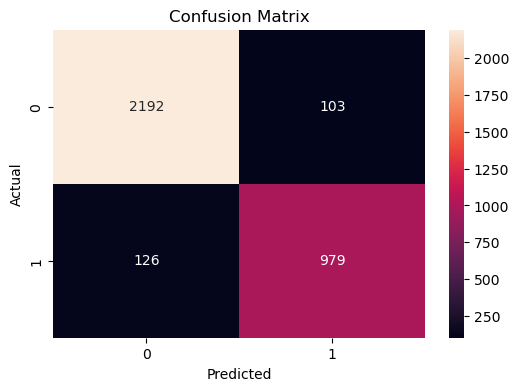

In [36]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2295
           1       0.90      0.89      0.90      1105

    accuracy                           0.93      3400
   macro avg       0.93      0.92      0.92      3400
weighted avg       0.93      0.93      0.93      3400



In [40]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
svm_model = SVC(
    kernel='rbf',   # most commonly used
    C=1.0,
    gamma='scale'
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Train model
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9305882352941176

Confusion Matrix:
 [[2185  110]
 [ 126  979]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      2295
           1       0.90      0.89      0.89      1105

    accuracy                           0.93      3400
   macro avg       0.92      0.92      0.92      3400
weighted avg       0.93      0.93      0.93      3400

